# Phase III: Envelope optimization integrated into surroundings

**Building:** Linear Building · **Model:** `models/linear_envelope_wwr15.idf` · **Weather:** `weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw` · **Output:** `results/linear_envelope_wwr15_results.csv`

Multi-objective optimization (NSGA-II via BESOS) minimizing cooling and heating demand with nine envelope and natural-ventilation variables. Run this notebook from its own folder (paths are relative to `notebooks/`).

## Envelope optimization


### *Import* of libraries

In [1]:
from besos import eppy_funcs as ef
from besos import eplus_funcs as ep
from besos.problem import EPProblem
from besos.objectives import *
from besos.evaluator import EvaluatorEP
from besos.parameters import wwr, RangeParameter, FieldSelector, FilterSelector, GenericSelector, Parameter, expand_plist
from besos.optimizer import NSGAII, SPEA2
from platypus.evaluator import MapEvaluator
import platypus
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dask.distributed import Client

### Simulation Model

In [2]:
building = ef.get_building('../models/linear_envelope_wwr15.idf') # Loading the E+ model;

### Variables

In [3]:
parameters = []

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_north",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - North Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_south",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - South Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_east",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - East Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_west",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - West Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_roof",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - Ext. Roof',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Ext mortar",    # Object name;
                    field_name="Solar Absorptance", # Object field;
                ),
                name='SA - Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.2, max_val=0.8)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Fibercement tile",    # Object name;
                    field_name="Solar Absorptance", # Object field;
                ),
                name='SA - Ext. Roof',
                value_descriptor=RangeParameter(min_val=0.2, max_val=0.8)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="WINDOWMATERIAL:GLAZING",   # Class of E+;
                    object_name="Clear 3mm",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='Glazing - Thickness',
                value_descriptor=RangeParameter(min_val=0.003, max_val=0.01)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="SCHEDULE:COMPACT",             # Class of E+;
                    object_name="VN_19",    # Object name;
                    field_name="Field 4", # Object field;
                ),
                name='AFN - Setpoint',
                value_descriptor=RangeParameter(min_val=18, max_val=25)      # Range
                )
            )


### Selection of the analysis objectives

In [4]:
demanda_resf = MeterReader('DistrictCooling:HVAC', name="Cooling demand (kWh/m²)")
demanda_aquec = MeterReader('DistrictHeating:HVAC', name="Heating demand (kWh/m²)")
EPobjectives = [demanda_resf,demanda_aquec] # cooling and heating as objectives;
problem = EPProblem(parameters, EPobjectives)  # Creating an instance of the problem;

### NSGA-II evaluation function and parameters definition + runtime

In [5]:
evaluator = EvaluatorEP(problem, building, epw="../../../weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw")   # Evaluation function with the problem and the model;
startTime = datetime.now()
results = NSGAII(evaluator, evaluations=500, population_size=100)   # running the NSGA-II;
print(datetime.now() - startTime)

1 day, 4:22:18.005710


### Results

In [6]:
results

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.149981,0.147203,0.148247,0.138962,0.146483,0.780634,0.799783,0.007390,24.073045,2.105850e+11,4.134181e+08,0,True
1,0.000266,0.016225,0.051546,0.012610,0.018743,0.202596,0.200221,0.003093,19.443375,7.313816e+10,1.743054e+11,0,True
2,0.005124,0.052893,0.011700,0.053506,0.087191,0.205402,0.202366,0.004565,21.372619,7.664846e+10,4.721372e+10,0,True
3,0.006215,0.048417,0.007869,0.053112,0.069432,0.207000,0.200158,0.009833,20.814599,7.603400e+10,1.405197e+11,0,True
4,0.148319,0.141104,0.149115,0.100535,0.148104,0.583518,0.624175,0.008119,22.977264,1.456832e+11,5.590313e+08,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.095026,0.057883,0.029875,0.101970,0.112160,0.271729,0.292851,0.006981,21.610471,1.009813e+11,7.201327e+09,0,False
96,0.045038,0.012191,0.107695,0.008804,0.027149,0.202596,0.267270,0.003886,21.115034,8.704660e+10,2.522517e+10,0,False
97,0.082789,0.146706,0.128691,0.084606,0.142570,0.724789,0.548852,0.009721,22.659369,1.313154e+11,1.875005e+09,0,False
98,0.010847,0.127585,0.084991,0.058468,0.095026,0.207723,0.462273,0.007951,22.022108,8.462770e+10,3.088679e+10,0,False


### *Plot* of the results (heating and cooling demand in kWh/m²·year)

In [7]:
import math
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']*pow(10,-9))
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']*pow(10,-9))
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/0.0036)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/0.0036)
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/884)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/884)

results

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.149981,0.147203,0.148247,0.138962,0.146483,0.780634,0.799783,0.007390,24.073045,66.764645,0.131072,0,True
1,0.000266,0.016225,0.051546,0.012610,0.018743,0.202596,0.200221,0.003093,19.443375,23.187988,55.262412,0,True
2,0.005124,0.052893,0.011700,0.053506,0.087191,0.205402,0.202366,0.004565,21.372619,24.300907,14.968810,0,True
3,0.006215,0.048417,0.007869,0.053112,0.069432,0.207000,0.200158,0.009833,20.814599,24.106097,44.550885,0,True
4,0.148319,0.141104,0.149115,0.100535,0.148104,0.583518,0.624175,0.008119,22.977264,46.187930,0.177237,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.095026,0.057883,0.029875,0.101970,0.112160,0.271729,0.292851,0.006981,21.610471,32.015490,2.283135,0,False
96,0.045038,0.012191,0.107695,0.008804,0.027149,0.202596,0.267270,0.003886,21.115034,27.597571,7.997478,0,False
97,0.082789,0.146706,0.128691,0.084606,0.142570,0.724789,0.548852,0.009721,22.659369,41.632696,0.594458,0,False
98,0.010847,0.127585,0.084991,0.058468,0.095026,0.207723,0.462273,0.007951,22.022108,26.830673,9.792460,0,False


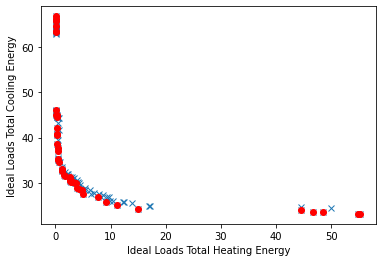

In [8]:
optres = results.loc[results['pareto-optimal']==True,:] # pareto-optimal
plt.plot(results['Heating demand (kWh/m²)'], results['Cooling demand (kWh/m²)'],'x') # Plot all results in 'x'
plt.plot(optres['Heating demand (kWh/m²)'], optres['Cooling demand (kWh/m²)'],'ro') # Plot of the best solutions in red
plt.xlabel('Ideal Loads Total Heating Energy')
plt.ylabel('Ideal Loads Total Cooling Energy')
plt.savefig("../results/linear_envelope_wwr15_pareto.png")
#plt.axis([0.00,0.08,0.0,1.6]) #Set the dimension of the chart

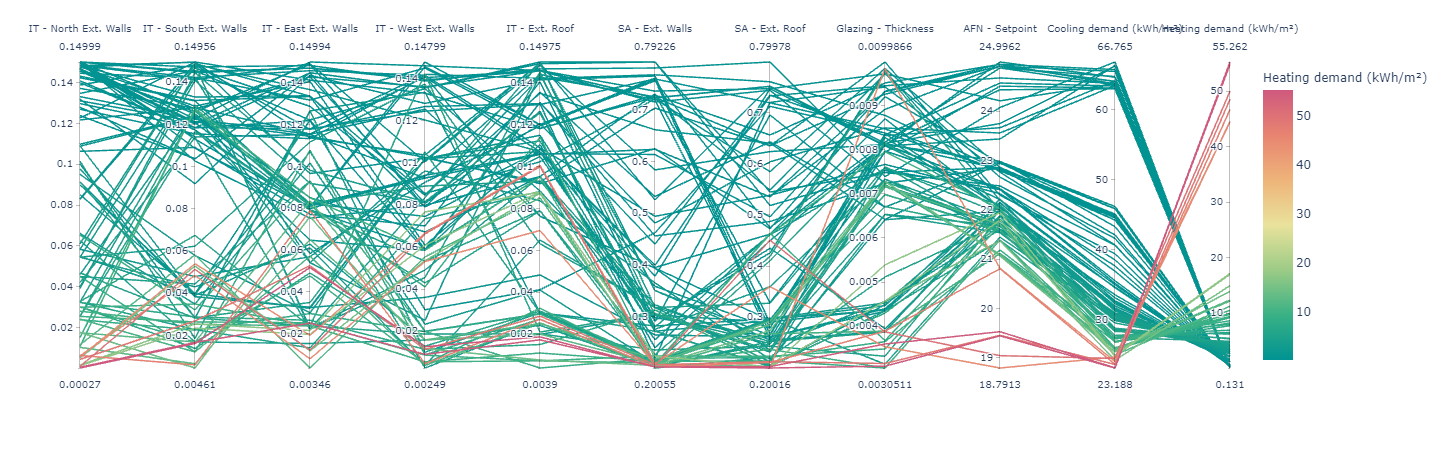

In [9]:
import plotly
plotly.offline.init_notebook_mode(connected=True)
import plotly.express as px
fig = px.parallel_coordinates(results,color="Heating demand (kWh/m²)", dimensions=["IT - North Ext. Walls","IT - South Ext. Walls","IT - East Ext. Walls","IT - West Ext. Walls","IT - Ext. Roof","SA - Ext. Walls","SA - Ext. Roof", "Glazing - Thickness", "AFN - Setpoint", "Cooling demand (kWh/m²)","Heating demand (kWh/m²)" ],
    color_continuous_scale=px.colors.diverging.Temps)
fig.show()

In [10]:
optres

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.149981,0.147203,0.148247,0.138962,0.146483,0.780634,0.799783,0.007390,24.073045,66.764645,0.131072,0,True
1,0.000266,0.016225,0.051546,0.012610,0.018743,0.202596,0.200221,0.003093,19.443375,23.187988,55.262412,0,True
2,0.005124,0.052893,0.011700,0.053506,0.087191,0.205402,0.202366,0.004565,21.372619,24.300907,14.968810,0,True
3,0.006215,0.048417,0.007869,0.053112,0.069432,0.207000,0.200158,0.009833,20.814599,24.106097,44.550885,0,True
4,0.148319,0.141104,0.149115,0.100535,0.148104,0.583518,0.624175,0.008119,22.977264,46.187930,0.177237,0,True
5,0.142296,0.131108,0.081498,0.093626,0.143870,0.719051,0.278287,0.008333,24.569878,63.352049,0.166006,0,True
6,0.004473,0.026906,0.052415,0.011359,0.028633,0.206791,0.212584,0.003153,19.454721,23.690075,48.551753,0,True
7,0.011616,0.058214,0.003462,0.055324,0.085020,0.209031,0.202366,0.004565,21.372619,25.047175,11.248216,0,True
8,0.000640,0.016699,0.024943,0.008964,0.017334,0.202685,0.202879,0.003595,19.527605,23.216397,54.804162,0,True
9,0.023894,0.022592,0.029521,0.019773,0.029619,0.209910,0.292255,0.006986,21.590395,26.891004,7.739157,0,True


In [11]:
results.to_csv('../results/linear_envelope_wwr15_results.csv')

In [12]:
min_idealloads = results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']
min_idealloads = min_idealloads[min_idealloads == min_idealloads.min()]
bestone = results[(results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']) == min_idealloads.min()]
bestone

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
11,0.032424,0.022836,0.01309,0.073433,0.088059,0.200555,0.221099,0.005113,21.706234,27.528082,4.94412,0,True
